# Overview
Here, we will perform the first step when creating machine learning, exporatory data analysis. We
will analyze many different attributes and verify their relationship with the classicification of an
email (is it spam?).

## Setup

In [312]:
# use this cell to install all requirements for this project.
# !pip install -r requirements.txt

In [313]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Our data follows the following format:

column         | dtype  | desciption
---------------|--------|---------------------------------------------------
filename       | str    | filename of the given file
from           | str    | domain of email sender
to             | str    | domain of email recipient
return_path    | str    | domain of the return email
message_id     | str    | domain of the 'Message-Id' header
recieved       | int    | number of entries in the 'Recieved' header
deliver_to     | int    | number of entries in the 'Deliver-To' header
weekday        | str    | day of week - (mon, tue, wed, etc.)
day            | str    | DD
month          | str    | MMM
year           | int    | YYYY
timezone       | str    | timezone of datetime, in UTC offset format
subject        | object | array of words within the subject, stemmed
body           | object | array of words within the body, stemmed


In [314]:
# import data
df = pd.read_csv('data/processed_emails.csv', index_col='filename')
df

,body,from,weekday,day,month,year,hour,timezone,to,subject,return_path,received,delivered_to,message_id,spam
filename,,,,,,,,,,,,,,,
01128.efb36914ecb55d78a894591eff0843c5,"['on', 'sun', 'NUMBER', 'jul', 'NUMBER', 'NUMB...",uni.de,sun,21,jul,2002,20,-400.0,freshrpms.net,"['re', 'ximian', 'apt', 'repo']",freshrpms.net,7,1,uni.de,False
00659.02e6dd777f837798533eae8f3b6a0491,"['what', 'is', 'mime', 'mime', 'stand', 'for',...",docserver.cac.washington.edu,mon,19,aug,2002,23,-700.0,example.sourceforge.net,"['wm', 'the', 'mime', 'inform', 'you', 'reques...",example.sourceforge.net,6,1,docserver.cac.washington.edu,False
00776.7df92458e9cf04b8873c406bde7d2fbe,"['im', 'not', 'up', 'to', 'fork', 'the', 'text...",golux.com,tue,13,aug,2002,15,-400.0,xent.com,"['a', 'messag', 'for', 'our', 'time']",xent.com,6,2,golux.com,False
00116.409b29c26edef06268b4bfa03ef1367a,"['on', 'sat', 'jul', 'NUMBER', 'NUMBER', 'at',...",skynet.ie,sat,20,jul,2002,13,100.0,linux.ie,"['re', 'ilug', 'vanquish', 'the', 'daemon', 'o...",linux.ie,8,1,skynet.ie,False
00615.23556d88fcb1179b25083cfc41017f42,"['origin', 'messag', 'date', 'thu', 'NUMBER', ...",dmv.com,thu,8,aug,2002,16,-400.0,example.sourceforge.net,"['re', 'razorus', 'use', 'razor', 'with', 'non...",example.sourceforge.net,7,1,landshark,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01311.43bfe86df65d53c5f7ca2365dc12582b,"['ffffffa9', 'copyright', 'NUMBER', 'all', 'ri...",bol.com.br,mon,05,aug,2002,21,-1700.0,dogma.slashnull.org,"['best', 'rate', 'on', 'mortgag', 'in', 'the',...",bol.com.br,4,1,mail.sunwaytech.com.cn,True
00851.dc5452f80ba0bb8481dfc48f70380c4d,"['creditfix', 'thank', 'you', 'your', 'email',...",msn.com,sun,21,jul,2002,10,-1700.0,netnv.net,"['fix', 'your', 'credit', 'yourself', 'onlin',...",msn.com,6,1,smtp-gw-4.msn.com,True
01328.b23902de23cb3ca1f3334517282372b2,"['hello', 'are', 'you', 'satisfi', 'with', 'yo...",yahoo.com,wed,07,aug,0102,16,1000.0,spamassassin.taint.org,"['new', 'internet', 'servic', 'provid']",xent.com,10,2,ccitih,True


# Exploratory Data Analysis
First, we will look through the DataFrame, search for any interesting statistics or correlated
attributes. To achieve this, we will look at various statistics and visualize/plot different 
attributes against each other.

On an initial look, features like delivered_to, recieved, and all date related features may give 
some correlation to spam.

In [315]:
# dataframe search
df.info()

<class 'pandas.DataFrame'>
Index: 3046 entries, 01128.efb36914ecb55d78a894591eff0843c5 to 00788.b98a23c07d59156d172683fc29b80661
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   body          3046 non-null   str    
 1   from          3045 non-null   str    
 2   weekday       3046 non-null   str    
 3   day           3046 non-null   str    
 4   month         3046 non-null   str    
 5   year          3046 non-null   str    
 6   hour          3046 non-null   int64  
 7   timezone      2900 non-null   float64
 8   to            2989 non-null   str    
 9   subject       3040 non-null   str    
 10  return_path   2829 non-null   str    
 11  received      3046 non-null   int64  
 12  delivered_to  3046 non-null   int64  
 13  message_id    2721 non-null   str    
 14  spam          3046 non-null   bool   
dtypes: bool(1), float64(1), int64(3), str(10)
memory usage: 359.9+ KB


In [316]:
# it appears our day and weekday values were interpreted as strings...  lets look furthur
df.day.value_counts()

day
19     177
24     176
21     173
22     156
23     141
25     128
20     123
31     112
13      99
17      88
30      88
12      86
26      85
18      84
11      75
16      75
28      74
2       73
29      67
9       65
27      65
8       63
6       58
15      58
14      57
3       52
10      52
5       50
1       46
7       45
4       41
05      40
06      39
09      37
04      35
02      35
01      34
03      34
08      29
07      29
May      2
Name: count, dtype: int64

In [317]:
# there are two emails where May is being held within the day field. lets drop these data points
df = df[df.day != 'May']

In [318]:
# alter certain types to numeric
df = df.astype({
    'body': 'object',
    'subject': 'object',
    'day' : 'int64',
    'weekday': 'category',
    'month': 'category',
    'year': 'int64',
    'timezone': 'category'
})

df.info()

<class 'pandas.DataFrame'>
Index: 3044 entries, 01128.efb36914ecb55d78a894591eff0843c5 to 00788.b98a23c07d59156d172683fc29b80661
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   body          3044 non-null   object  
 1   from          3043 non-null   str     
 2   weekday       3044 non-null   category
 3   day           3044 non-null   int64   
 4   month         3044 non-null   category
 5   year          3044 non-null   int64   
 6   hour          3044 non-null   int64   
 7   timezone      2898 non-null   category
 8   to            2987 non-null   str     
 9   subject       3038 non-null   object  
 10  return_path   2827 non-null   str     
 11  received      3044 non-null   int64   
 12  delivered_to  3044 non-null   int64   
 13  message_id    2719 non-null   str     
 14  spam          3044 non-null   bool    
dtypes: bool(1), category(3), int64(5), object(2), str(4)
memory usage: 297.7+ KB


In [319]:
# convert body and subject back to lists
import ast

df['body'] = df.body.apply(ast.literal_eval)
df['subject'] = df.subject.apply(lambda row: ast.literal_eval(row) if (isinstance(row, str) and len(row) > 0) else [])

In [320]:
# as a sanity check, lets check other fields
df.weekday.value_counts(), df.month.value_counts(), df.timezone.value_counts()

(weekday
 wed    553
 tue    526
 mon    476
 fri    460
 thu    445
 sun    307
 sat    277
 Name: count, dtype: int64,
 month
 jul    1293
 aug    1075
 may     338
 jun     190
 nov      30
 sep      27
 apr      21
 dec      19
 mar      18
 feb      17
 oct      12
 jan       4
 Name: count, dtype: int64,
 timezone
  100.0     596
 -400.0     592
 -700.0     528
 -500.0     286
  200.0     173
  0.0       117
 -1900.0    114
 -1600.0    105
  800.0      90
 -600.0      43
 -800.0      34
  530.0      28
 -1700.0     24
  300.0      24
  900.0      19
 -300.0      18
  1000.0     15
 -1800.0     13
  1200.0     13
  700.0      10
 -1000.0      7
 -900.0       7
 -1100.0      5
 -200.0       5
 -100.0       5
  500.0       5
  600.0       5
 -2200.0      4
 -1200.0      4
  400.0       4
  1100.0      4
 -2000.0      1
 Name: count, dtype: int64)

In [321]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
body,3044,2815,"[dear, homeown, NUMBER, NUMBER, yr, fix, rate,...",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
from,3043,951,hotmail.com,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday,3044,7,wed,553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,3044.0,NaN,NaN,NaN,16.836071,8.685304,1.0,9.0,19.0,24.0,31.0
month,3044,12,jul,1293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,3044.0,NaN,NaN,NaN,1958.162286,287.47359,1.0,2002.0,2002.0,2002.0,2020.0
hour,3044.0,NaN,NaN,NaN,12.377464,6.390905,0.0,8.0,13.0,17.0,23.0
timezone,2898.0,32.0,100.0,596.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,2987,506,spamassassin.taint.org,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,3044,2109,"[re, ilug, suse, NUMBER, disk, thread, chang, ...",34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [322]:
# there is also some instances where year is or 1 or 0, lets drop these as well
df = df[df.year >= 1970]

In [323]:
# number of spam emails, number of ham emails
len(df[df.spam == True]), len(df[df.spam == False])

(1325, 1650)

### Numerical EDA
Among our numerical values, we have many discrete features which can be plotted with spam for
greater understanding:
- Recieved
- Delivered-To
- Year (in practice the year would not be relevant in a spam classifier
which detects spam in current emails, so we can drop year)
- Day
- Hour


In [324]:
def plot_discrete(x_var, ttl):
    _, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    sns.boxplot(data=df, x=x_var, hue='spam', showfliers=True, ax=axes[0,0])
    axes[0,0].set(title=ttl + ' vs. Spam', xlabel=ttl, ylabel='Spam')

    sns.histplot(
        data=df, x=x_var, ax=axes[0,1], hue='spam',
        discrete=True, color='#ff7f0e', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[0,1].set(title=ttl + ' Distribution', xlabel=ttl, ylabel='Density')

    sns.histplot(
        data=df[df.spam == False], x=x_var, ax=axes[1,0], 
        discrete=True, color='#1f77b4', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[1,0].set(title=ttl + ' Distribution (Ham)', xlabel=ttl, ylabel='Density')

    sns.histplot(
        data=df[df.spam == True], x=x_var, ax=axes[1,1], 
        discrete=True, color='#ff7f0e', stat='density',
        binrange=(df[x_var].min(), df[x_var].max())
    )
    axes[1,1].set(title=ttl + ' Distribution (Spam)', xlabel=ttl, ylabel='Density')

    plt.show()

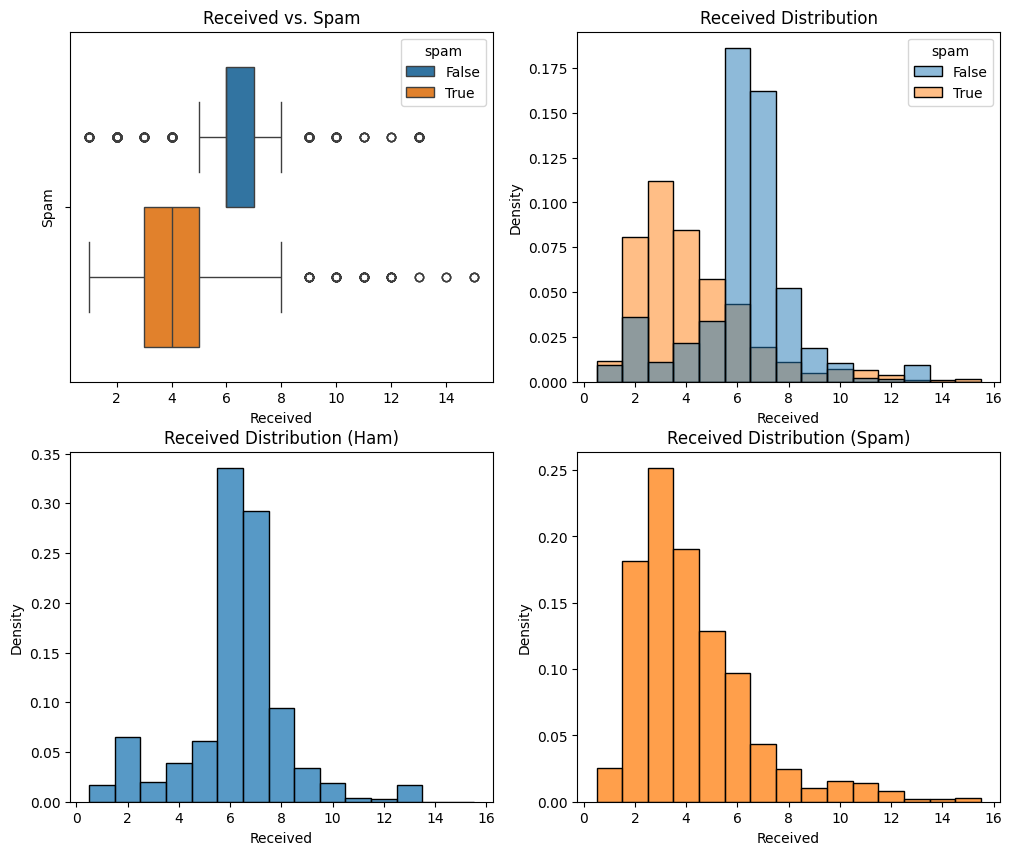

In [325]:
# a colored box plot would sufficiently show the distributions between recieved on spam or ham
plot_discrete('received', 'Received')

It is apparent that an the amount of entries in the Recieved header of an email is typically shorter
when it is spam, as opposed to ham.

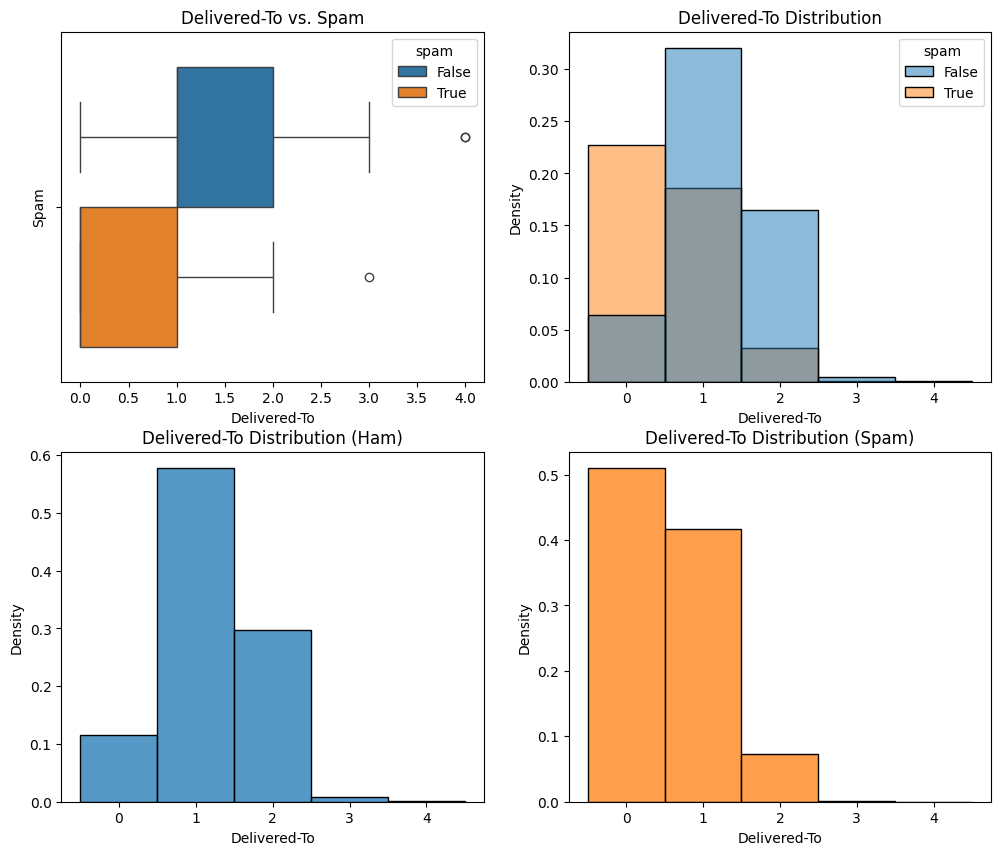

In [326]:
# Delivered-To
plot_discrete('delivered_to', 'Delivered-To')

It is apparent that an the amount of entries in the Delivered-To header of an email is typically shorter
when it is spam, as opposed to ham.

We can perform some feature engineering here. Typically, the Received and Delivered-To headers are
coupled together, as they correspond to the path an email had taken to reach a user. As such, we can
combine the two counts of entries to a new feature, titled `path_length`.

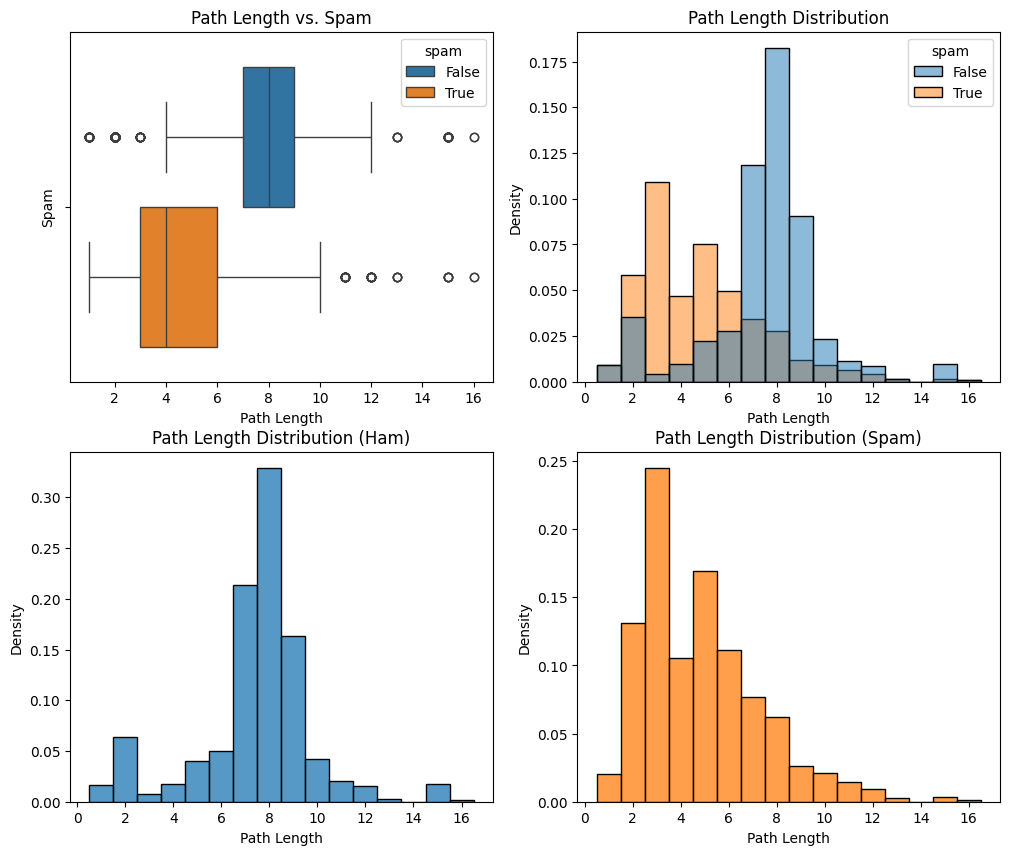

In [327]:
df['path_length'] = df.received + df.delivered_to

# we can now plot this
plot_discrete('path_length', 'Path Length')

Supporting our previous awknowledgements, the path length is found to typically be shorter in spam 
emails. It also appears that the path length is much more skewed in spam, as opposed to ham with its
normally distributed path length.

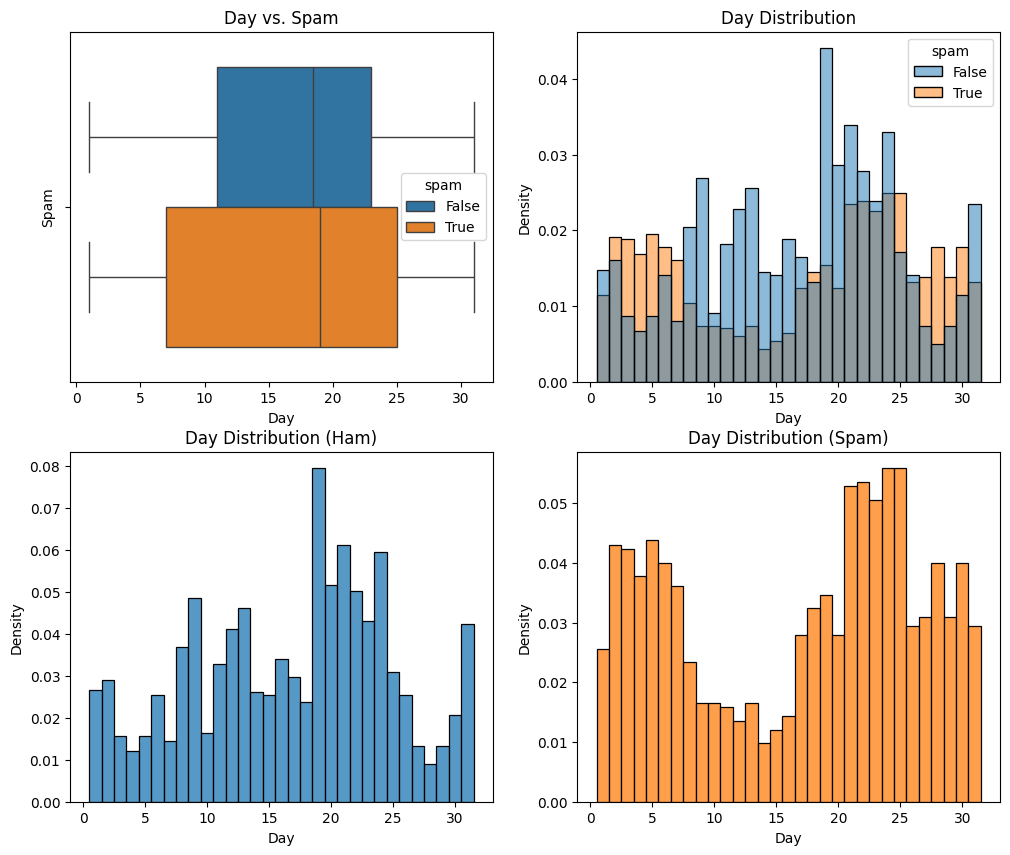

In [328]:
# Day
plot_discrete('day', 'Day')

When we look at the Day feature, we can see that ham emails do not particularly follow any 
distribution. However spam follows a bimodal distribution, with more spam being sent at the end or
beginning of the month.

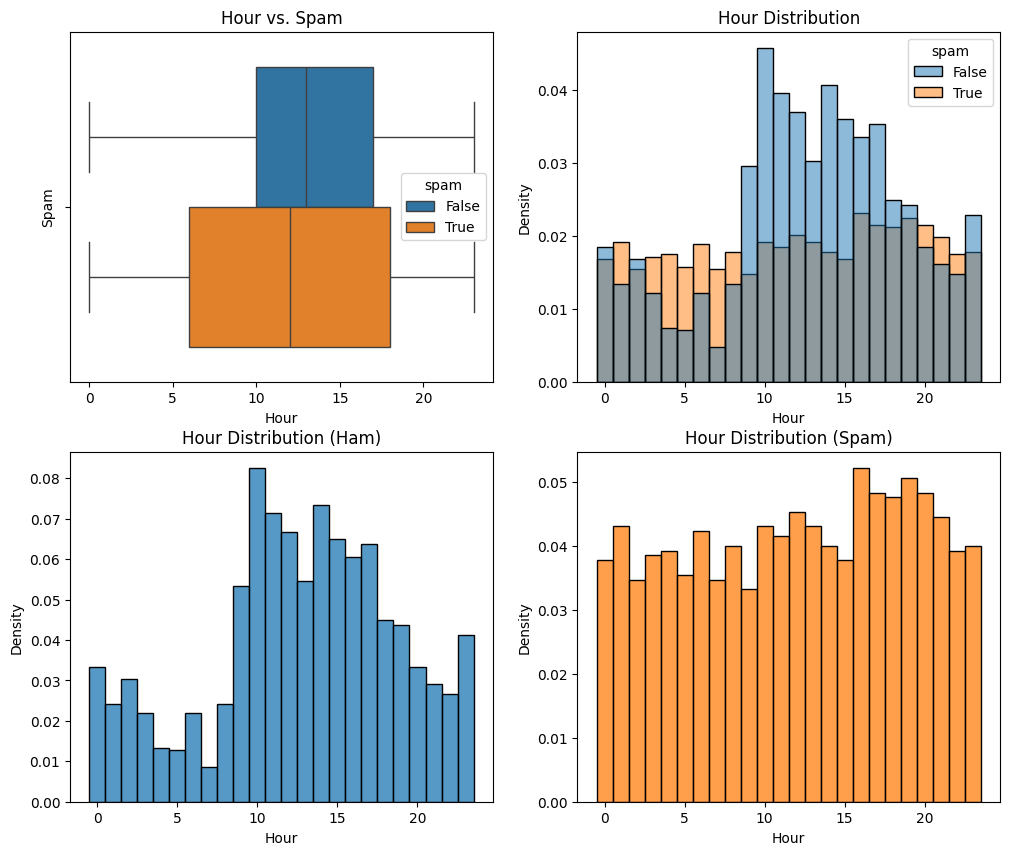

In [329]:
# Hour
plot_discrete('hour', 'Hour')

On first glance, the distributions seem very similar. Yet, when comparing the two distributions, it 
becomes clear that spam is sent at all times of the day with a uniform distribution. Yet ham is 
sent much more often at 10:00-16:00, with little ham being sent in the beginning of the day.

#### Numerical EDA Conclusions
Given our analysis of numerical features within this dataset. We have made the following 
obeservations:
- The amount of entries in the Recieved header of an email is typically shorter
when it is spam, as opposed to ham.
- The amount of entries in the Delivered-To header of an email is typically shorter
when it is spam, as opposed to ham.
- The path length is found to typically be shorter in spam emails. The path length distribution is 
much more  skewed in spam, as opposed to ham with its normally distributed path length.
- Ham emails do not particularly follow any Day distribution. However, spam follows a bimodal 
distribution, with more spam being sent at the end or beginning of the month.
- Spam is sent at all times of the day, with a uniform distribution. Yet ham is sent much more often 
around 10:00-16:00, with little ham being sent in the beginning of the day.

## Continuous EDA

Again, we can perform more feature engineering, by creating features which correspond to the length
(word count) of `body` and `subject`, we may be able to extract some information. We will treat this
as a continuous variable, as it has a large variable range.

In [330]:
df['body_len'] = df.body.apply(len)
df['subject_len'] = df.subject.apply(len)
df[['body_len', 'subject_len']].describe()

,body_len,subject_len
count,2975.000000,2975.000000
mean,340.642689,5.869916
std,676.331602,3.264132
min,0.000000,0.000000
25%,95.000000,4.000000
50%,165.000000,6.000000
75%,322.500000,7.000000
max,14254.000000,104.000000


In [331]:
# there is an email with an extreme amount of words! lets see what it is...
df.iloc[df.body_len.argmax()]

body            [yahoo, group, sponsor, NUMBER, dvds, free, sp...
from                                           saul.cis.upenn.edu
weekday                                                       mon
day                                                            19
month                                                         aug
year                                                         2002
hour                                                           21
timezone                                                   -400.0
to                                                    egroups.com
subject         [unisonannounc, new, unison, betareleas, NUMBE...
return_path                                    saul.cis.upenn.edu
received                                                        9
delivered_to                                                    2
message_id                                     saul.cis.upenn.edu
spam                                                        False
path_lengt

In [332]:
# define continuous plot
def plot_continuous(x_var, label):
    _, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    sns.violinplot(data=df, x=x_var, hue='spam', ax=axes[0,0], split=True)
    axes[0,0].set(title=label + ' vs. Spam', xlabel=label, ylabel='Spam')

    sns.kdeplot(
        data=df, x=x_var, ax=axes[0,1], hue='spam',
        color='#ff7f0e', fill=True
    )
    axes[0,1].set(title=label + ' Distribution', xlabel=label, ylabel='Density')

    sns.boxplot(data=df, x=x_var, hue='spam', ax=axes[1,0])
    axes[1,0].set(title=label + ' vs. Spam', xlabel=label, ylabel='Density')

    sns.boxplot(data=df, x=x_var, hue='spam', ax=axes[1,1], showfliers=False)
    axes[1,1].set(title=label + ' vs. Spam (outliers removed)', xlabel=label, ylabel='Density')

    plt.show()


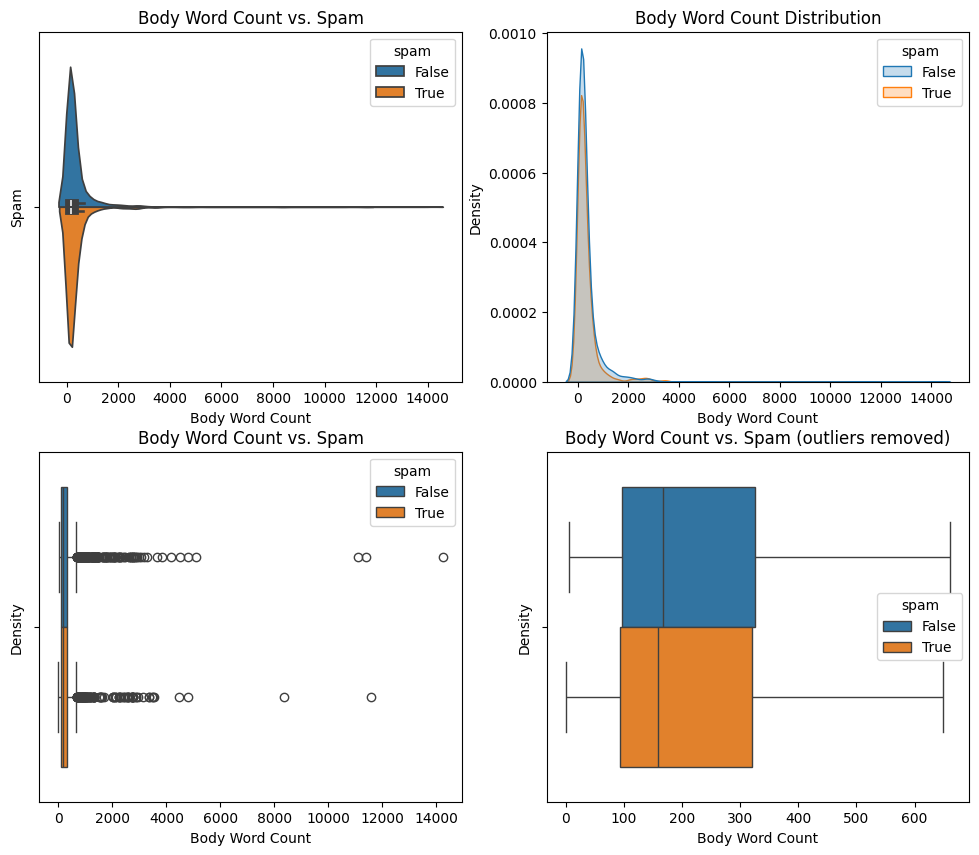

In [333]:
# body length
plot_continuous('body_len', 'Body Word Count')

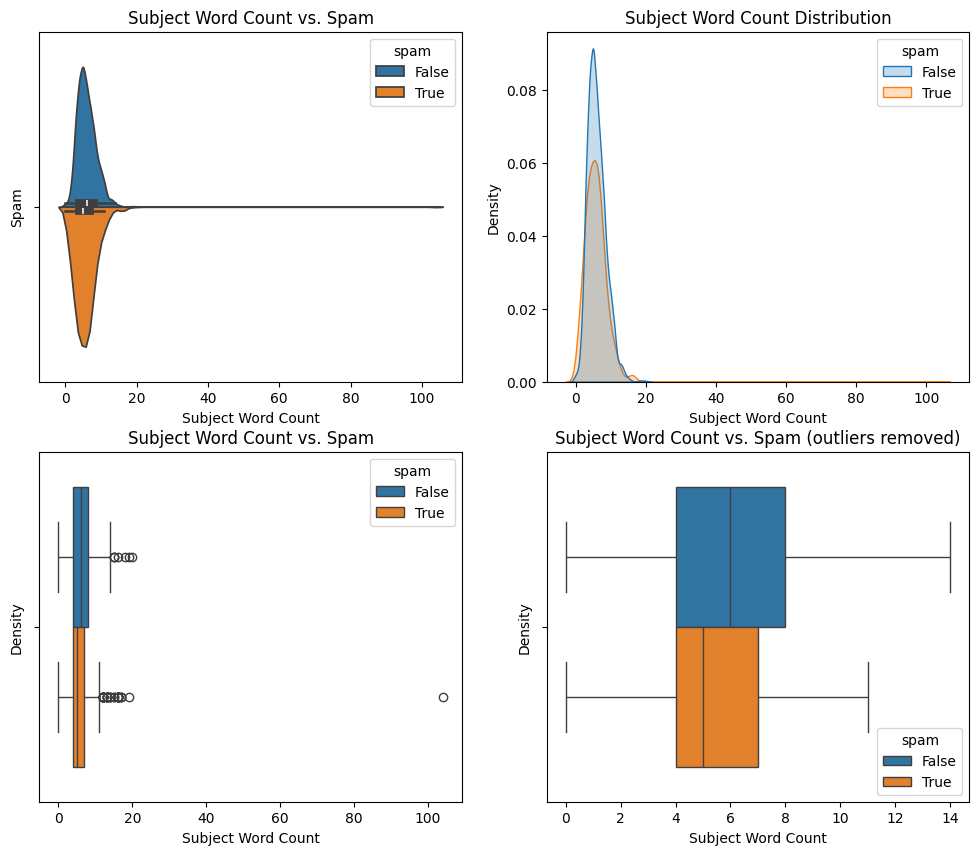

In [334]:
# subject length
plot_continuous('subject_len', 'Subject Word Count')

### Continuous EDA Conclusions
After analyzing our continuous data points:
- The word counts of the body and subject seem to be fairly consistent between spam and
ham, indicating a weak correlation between the features. However, both attributes contain extreme
outliers, signifying that standardization would be needed to process these features.

## Categorical EDA
As for categorical values, we have weekday and timezone. Lets analyze the impact the weekday/
timezone has on spam classification.

In [335]:
def plot_categorical(x_var, label):
    _, axes = plt.subplots(ncols=3, figsize=(28, 10), gridspec_kw={'width_ratios': [1, 1, 2]})
    
    crosstab = pd.crosstab(df[x_var], df['spam'], normalize='columns')

    ham = pd.DataFrame(crosstab[False])
    spam = pd.DataFrame(crosstab[True])

    sns.heatmap(ham, fmt='.2%', annot=True, cmap='Blues', ax=axes[0], xticklabels='')
    axes[0].set(title=label + ' vs. Ham', ylabel=label, xlabel='Ham')

    sns.heatmap(spam, fmt='.2%', annot=True, cmap='Oranges', ax=axes[1], xticklabels='')
    axes[1].set(title=label + ' vs. Spam', ylabel=label, xlabel='Spam')

    sns.countplot(data=df, y=x_var, hue='spam', ax=axes[2])
    axes[2].set(title=label + ' vs. Spam', ylabel=label, xlabel='Spam')

    plt.show()

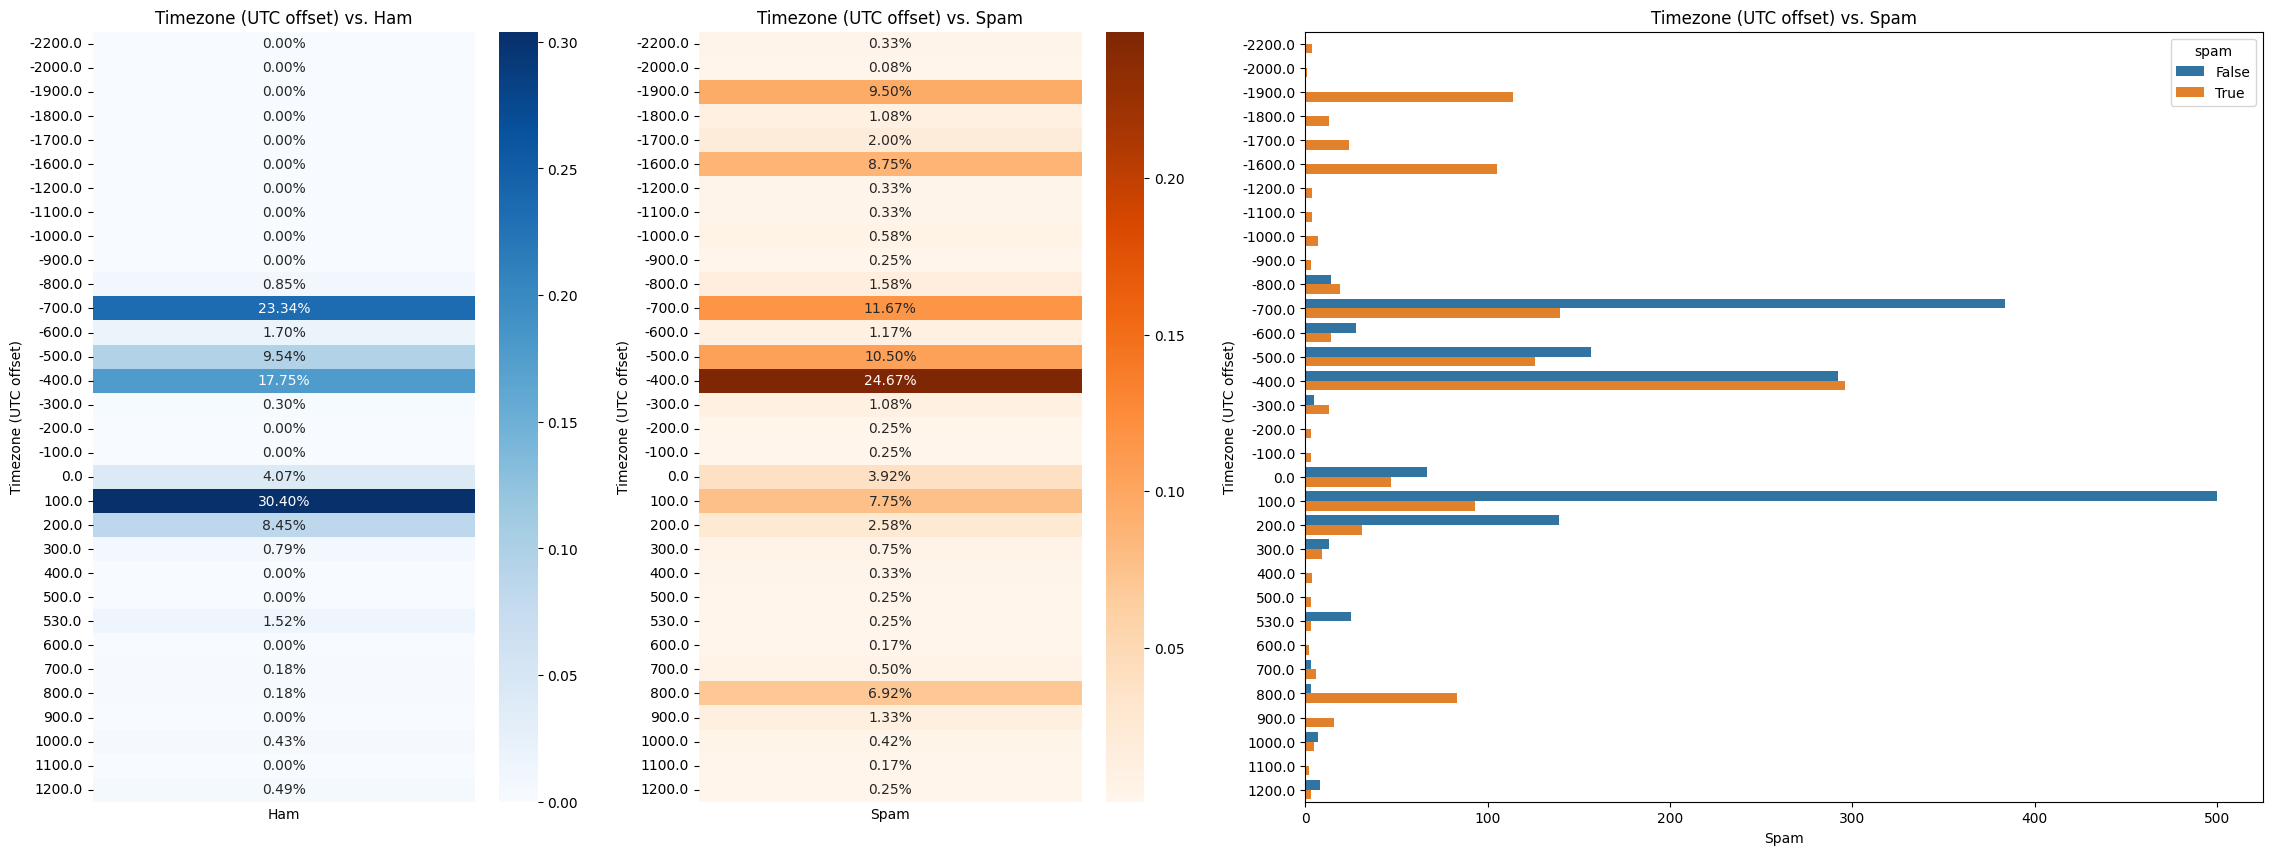

In [336]:
plot_categorical('timezone', 'Timezone (UTC offset)')

We can see that the majority of spam and ham are sent within the same timezones (UTC +100, -700, 
-400). Yet it appears that spam is sent throughout a much larger range of timezones. This may be
due to selection bias.

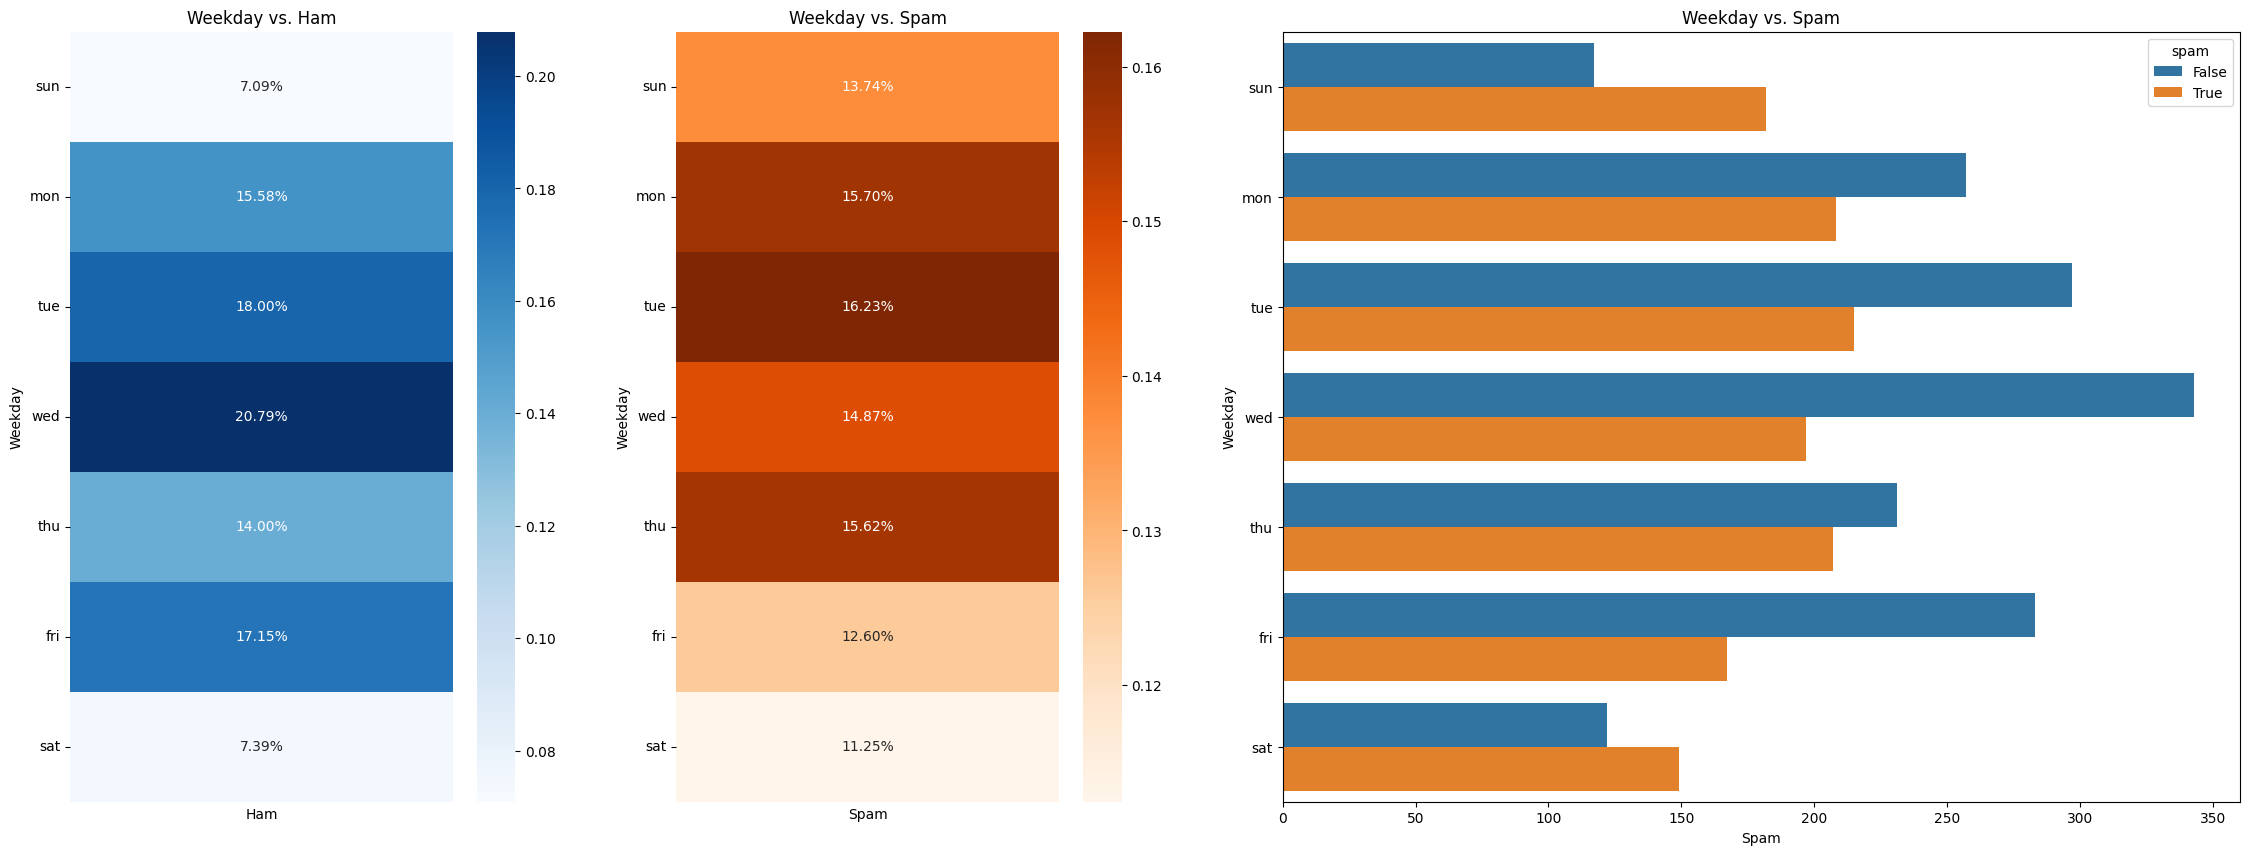

In [337]:
# weekday, we will use custom implementation to properly display the weekdays

def plot_weekdays():
    x_var='weekday'
    label='Weekday'
    days = ['sun', 'mon', 'tue', 'wed', 'thu', 'fri', 'sat']

    _, axes = plt.subplots(ncols=3, figsize=(28, 10), gridspec_kw={'width_ratios': [1, 1, 2]})
    
    crosstab = pd.crosstab(df[x_var], df['spam'], normalize='columns')
    crosstab = crosstab.reindex(days)

    ham = pd.DataFrame(crosstab[False])
    spam = pd.DataFrame(crosstab[True])

    sns.heatmap(ham, fmt='.2%', annot=True, cmap='Blues', ax=axes[0], xticklabels='')
    axes[0].set(title=label + ' vs. Ham', ylabel=label, xlabel='Ham')
    axes[0].set_yticklabels(days, rotation=0)

    sns.heatmap(spam, fmt='.2%', annot=True, cmap='Oranges', ax=axes[1], xticklabels='')
    axes[1].set(title=label + ' vs. Spam', ylabel=label, xlabel='Spam')
    axes[1].set_yticklabels(days, rotation=0)

    sns.countplot(data=df, y=x_var, hue='spam', ax=axes[2], order=days)
    axes[2].set(title=label + ' vs. Spam', ylabel=label, xlabel='Spam')

    plt.show()

plot_weekdays()

Spam overall appears to follow much more of a uniform distribution along the weekdays, with all days
seeing a ~10-16% proportion. Whereas ham is seen more often on the weekdays, little ham is sent
on weekends (as to be expected, nobody wants to work a weekend).

### Categorical Conclusions
After analyzing timezone and weekday, we can make the following observations:
- Due to potential selection bias, timezone may not be a viable attribute to include in a
classification model. (It will introduce bias towards timezones within America, as we don't have ham
from other timezones where we see spam).
- Ham is seen more often on the weekdays, with a small propotion of ham being sent on weekends. 
The day of the weekday may be a useful attribute to include in a model.

# Sparse Matrix
Within `body`, and `subject`, we have lists of stemmed words which can be absolutely critical in 
classifying whether or not an email is spam. To properly process these attributes, we can create
spare matrices, representing the presence of the most common words.

In [418]:
from sklearn.feature_extraction.text import TfidfVectorizer

def create_sparse_matrix(x_var):
    vectorizer = TfidfVectorizer(
        analyzer='word',
        tokenizer=lambda x : x,
        preprocessor=lambda x: x,
        token_pattern=None,
        min_df=.05, # ignore words in fewer than 5% of emails
        max_df= .95, # ignore words in more than 95% of emails
        max_features=100 # get top 100 words
    )

    corpus = df[x_var].to_list()
    X = vectorizer.fit_transform(corpus)
    return vectorizer, X

In [419]:
# create sparse matrices for body and subject.
body_vectorizer, body_sp = create_sparse_matrix('body')
subject_vectorizer, subject_sp = create_sparse_matrix('subject')

## Sparse Matrix EDA

In [420]:
def analyze_sparse_matrix(vectorizer, sparse_matrix):
    # print row of matrix
    X_0 = pd.Series(
        sparse_matrix[0].toarray().flatten(),
        vectorizer.get_feature_names_out()    
    )
    
    print('-------- example row --------')
    print(X_0)

    print('-------- average number of words per row: ', sparse_matrix.getnnz(axis=1).mean() , '--------')

    spam_mask = (df['spam'] == True).to_numpy()
    ham_mask = (df['spam'] == False).to_numpy()

    spam_freq = pd.Series(
        np.asarray(sparse_matrix[spam_mask].sum(axis=0)).flatten(),
        index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)

    ham_freq = pd.Series(
        np.asarray(sparse_matrix[ham_mask].sum(axis=0)).flatten(),
        index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)

    print('-------- spam frequencies --------')
    print(spam_freq.iloc[:10])

    print('-------- ham frequencies --------')
    print(ham_freq.iloc[:10])

In [421]:
analyze_sparse_matrix(body_vectorizer, body_sp)

-------- example row --------
NUMBER     0.281250
URL        0.342533
a          0.069359
about      0.000000
address    0.000000
             ...   
with       0.000000
work       0.066212
would      0.347516
you        0.000000
your       0.000000
Length: 100, dtype: float64
-------- average number of words per row:  39.12705882352941 --------
-------- spam frequencies --------
NUMBER    317.382035
to        270.157749
the       233.785868
you       229.344451
your      208.270856
and       197.241980
a         149.912005
of        146.431627
this      129.289879
click     129.120440
dtype: float64
-------- ham frequencies --------
the       466.114664
NUMBER    392.743576
to        310.269680
a         272.967732
i         249.082736
and       219.734619
of        217.003540
it        203.127278
URL       196.722852
that      183.672645
dtype: float64


In [422]:
analyze_sparse_matrix(subject_vectorizer, subject_sp)

-------- example row --------
NUMBER    0.0
a         0.0
for       0.0
ilug      0.0
re        1.0
the       0.0
to        0.0
your      0.0
dtype: float64
-------- average number of words per row:  1.1159663865546219 --------
-------- spam frequencies --------
NUMBER    287.227060
your      186.981209
for        95.946475
the        91.447093
to         82.241347
a          79.157640
re         32.969797
ilug        9.763414
dtype: float64
-------- ham frequencies --------
re        748.303754
ilug      335.219008
NUMBER    201.119288
the       154.509631
to        101.490336
a          68.728143
for        62.626361
your       17.394259
dtype: float64


### Spare Matrix Conclusions
Spam and Ham have different distributions of words within them, on a first glance, you can observe
that spam has a lot more language with words like 'click', 'free' in the body. Whereas Ham contains 
more casual wording, with more of the common words being present throughout. There is also the word 
'linux' seen frequently, which can be argued as a strong case of selection bias. Clearly the source 
of these emails come from a developer; as it is practically certain that the majority of emails on 
this planet do not speak about Linux.

In [423]:
df.head()

,body,from,weekday,day,month,year,hour,timezone,to,subject,return_path,received,delivered_to,message_id,spam,path_length,body_len,subject_len
filename,,,,,,,,,,,,,,,,,,
01128.efb36914ecb55d78a894591eff0843c5,"[on, sun, NUMBER, jul, NUMBER, NUMBER, NUMBER,...",uni.de,sun,21,jul,2002,20,-400.0,freshrpms.net,"[re, ximian, apt, repo]",freshrpms.net,7,1,uni.de,False,8,218,4
00659.02e6dd777f837798533eae8f3b6a0491,"[what, is, mime, mime, stand, for, multipurpos...",docserver.cac.washington.edu,mon,19,aug,2002,23,-700.0,example.sourceforge.net,"[wm, the, mime, inform, you, request, last, ch...",example.sourceforge.net,6,1,docserver.cac.washington.edu,False,7,419,11
00776.7df92458e9cf04b8873c406bde7d2fbe,"[im, not, up, to, fork, the, text, but, for, y...",golux.com,tue,13,aug,2002,15,-400.0,xent.com,"[a, messag, for, our, time]",xent.com,6,2,golux.com,False,8,26,5
00116.409b29c26edef06268b4bfa03ef1367a,"[on, sat, jul, NUMBER, NUMBER, at, 121857pm, N...",skynet.ie,sat,20,jul,2002,13,100.0,linux.ie,"[re, ilug, vanquish, the, daemon, of, shell, s...",linux.ie,8,1,skynet.ie,False,9,115,8
00615.23556d88fcb1179b25083cfc41017f42,"[origin, messag, date, thu, NUMBER, aug, NUMBE...",dmv.com,thu,8,aug,2002,16,-400.0,example.sourceforge.net,"[re, razorus, use, razor, with, nonmbox, file]",example.sourceforge.net,7,1,landshark,False,8,143,7


# Conclusions
We have performed EDA, as well as some feature extraction on many different key data points of this
dataset. We have made the following observations:
- The amount of entries in the `Recieved` header of an email is typically shorter
when it is spam, as opposed to ham.
- The amount of entries in the `Delivered-To` header of an email is typically shorter
when it is spam, as opposed to ham.
- The `path length` is found to typically be shorter in spam emails. The path length distribution is 
much more  skewed in spam, as opposed to ham with its normally distributed path length.
- Ham emails do not particularly follow any `Day` distribution. However, spam follows a bimodal 
distribution, with more spam being sent at the end or beginning of the month.
- Spam is sent at all **times** of the day, with a uniform distribution. Yet ham is sent much more often 
around 10:00-16:00, with little ham being sent in the beginning of the day.
- The **word counts** of the body and subject seem to be fairly consistent between spam and
ham, indicating a weak correlation between the features. However, both attributes contain extreme
outliers, signifying that standardization would be needed to process these features.
- Due to potential selection bias, `timezone` may not be a viable attribute to include in a
classification model. (It will introduce bias towards timezones within America, as we don't have ham
from other timezones where we see spam).
- Ham is seen more often on the **weekdays**, with a small propotion of ham being sent on weekends. 
The day of the weekday may be a useful attribute to include in a model.
- Spam and ham use different language seen in the `body` and `subject`.

With these observations, we can create a list of viable features to include during preprocessing:
- **Recieved** (standardized, due to outliers)
- **Delivered** (standardized)
- **Path Length** (standardized)
- **Day** (cyclical encoding)
- **Hour** (cyclical encoding)
- **Weekdays** (one-hot-encoding)
- **Body** (sparse matrix)
- **Subject** (spare matrix)

Where the following features were not selected for preprocessing:
- **Timezone** (due to selection bias)
- **Year** (irrelevant to the problem)
- **From** (selection bias)
- **To** (selection bias)
- **Return Path** (selection bias)
- **Message Id** (selection bias)
- **Body length** (weak relationship to spam)
- **Subject** length (weak relationship to spam)

We will continue preprocessing and create processing pipeline in 
[preprocessing.ipynb](preprocessing.ipynb).